# Represent interannual variability analytically as binomial probability of exceedance

In [1]:
# necessary: netcdf4-python, regionmask, (xarray, geopandas), cartopy, openpyxl, statsmodels

import numpy as np
import pandas as pd
import os, glob, re 
import math
import xarray as xr
import geopandas as gpd
import regionmask as regionmask
import dask
import matplotlib.pyplot as plt
import netCDF4

%matplotlib inline

#plotting
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from scipy.stats import norm

# import my variables settings functions from other scripts
from settings import *
from functions import *
from utils import *
from plotscript import *


# import dem4cli
sys.path.append(os.path.join(os.environ['VSC_DATA_VO_USER'],'demographics4climate/'))
from population_demographics import * 


In [ ]:
# def calc_nAHD_shift_MC(
#     da_params,
#     threshold,
#     gmst_smo,
#     n_draws=1000,
#     year_pres=2023,
#     GWI=1.3
# ):

#     # ---- GMST ----
#     gmst_pres = gmst_smo.loc[year_pres].values

#     # ---- Parameters (dims: dataset, month, lat, lon) ----
#     b0 = da_params.sel(params='b0')
#     b1 = da_params.sel(params='b1')
#     sigma = da_params.sel(params='sigma')

#     # ---- Mean field ----
#     mu = b0 + b1 * gmst_pres   # same dims as b0

#     # Convert to numpy arrays
#     mu_np = mu.values
#     sigma_np = sigma.values

#     # ---- Monte Carlo sampling ----
#     # Add new leading draw dimension
#     X_sim = np.random.normal(
#         loc=mu_np[None, ...],        # add draw dimension
#         scale=sigma_np[None, ...],   # broadcast correctly
#         size=(n_draws,) + mu_np.shape
#     )

#     # ---- Days per month ----
#     days_in_month = np.array([31,28,31,30,31,30,31,31,30,31,30,31])

#     # reshape for broadcasting: (1, 1, month, 1, 1)
#     days = days_in_month[None, None, :, None, None]

#     # ---- Threshold exceedance ----
#     exceed = (X_sim > threshold) * days

#     # ---- Sum over month dimension (axis=2) ----
#     nAHD_draws = exceed.sum(axis=2)

#     # ---- Convert back to xarray ----
#     da_nAHD_MC = xr.DataArray(
#         nAHD_draws,
#         dims=['draw', 'dataset', 'lat', 'lon'],
#         coords={
#             'draw': np.arange(n_draws),
#             'dataset': da_params.dataset,
#             'lat': da_params.lat,
#             'lon': da_params.lon
#         }
#     )

#     # ---- Percentiles per dataset (natural variability only) ----
#     da_nAHD_med = da_nAHD_MC.median(dim='draw')
#     da_nAHD_5 = da_nAHD_MC.quantile(0.05, dim='draw')
#     da_nAHD_95 = da_nAHD_MC.quantile(0.95, dim='draw')

#     return da_nAHD_MC, da_nAHD_med, da_nAHD_5, da_nAHD_95

In [ ]:

# def calc_nAHD_shift_MC(
#     da_params,
#     threshold,
#     gmst_smo,
#     n_draws=1000,
#     year_pres=2023,
#     GWI=1.3
# ):

#     # ---- GMST ----
#     gmst_pres = gmst_smo.loc[year_pres].values
#     gmst_pi = gmst_pres - GWI

#     # ---- Parameters (dims: dataset, month, lat, lon) ----
#     b0 = da_params.sel(params='b0')
#     b1 = da_params.sel(params='b1')

#     mu_pres_np = (b0 + b1 * gmst_pres).values
#     mu_past_np = (b0 + b1 * (gmst_pres - GWI)).values

#     if 'sigma_b1' in da_params.params:
#         sigma_b0 = da_params.sel(params='sigma_b0')
#         sigma_b1 = da_params.sel(params='sigma_b1')
#         sigma_pres_np = (sigma_b0 + sigma_b1 * gmst_pres).values
#         sigma_past_np = (sigma_b0 + sigma_b1 * (gmst_pres - GWI)).values
#     else:
#         sigma_pres_np = sigma_past_np = da_params.sel(params='sigma').values
    
#     # ---- Ensure sigma is physically valid ----
#     if np.any(sigma_pres_np < 0):
#         raise ValueError("Negative sigma detected in present climate")

#     if np.any(sigma_past_np < 0):
#         raise ValueError("Negative sigma detected in past climate")


#     # ---- Monte Carlo sampling ----
#     # random normal noise same for both 
#     Z = np.random.normal(
#     loc=0,
#     scale=1,
#     size=(n_draws,) + mu_pres_np.shape
#     )

#     # ---- Construct both fields with same noise ----
#     X_pres = mu_pres_np[None, ...] + sigma_pres_np[None, ...] * Z
#     X_past = mu_past_np[None, ...] + sigma_past_np[None, ...] * Z

#     # ---- Days per month ----
#     days_in_month = np.array([31,28,31,30,31,30,31,31,30,31,30,31])

#     # reshape for broadcasting: (1, 1, month, 1, 1)
#     days = days_in_month[None, None, :, None, None]

#     exceed_pres = (X_pres > threshold) * days
#     exceed_past = (X_past > threshold) * days

#     nAHD_pres = exceed_pres.sum(axis=2)
#     nAHD_past = exceed_past.sum(axis=2)

#     delta_nAHD = nAHD_pres - nAHD_past

#     # ---- Convert back to xarray ----
#     da_nAHD_MC = xr.DataArray(
#         delta_nAHD,
#         dims=['draw', 'dataset', 'lat', 'lon'],
#         coords={
#             'draw': np.arange(n_draws),
#             'dataset': da_params.dataset,
#             'lat': da_params.lat,
#             'lon': da_params.lon
#         }
#     )

#     # ---- Percentiles per dataset (natural variability only) ----

#     da_nAHD_med = da_nAHD_MC.quantile(0.5, dim='draw')
#     da_nAHD_5 = da_nAHD_MC.quantile(0.05, dim='draw')
#     da_nAHD_95 = da_nAHD_MC.quantile(0.95, dim='draw')

#     da_nAHD_summary = xr.concat([da_nAHD_med, da_nAHD_5, da_nAHD_95], dim='quantile')
        

#     return da_nAHD_MC, da_nAHD_summary


In [ ]:

# def calc_nAHD_shift_MC(
#     da_params,
#     threshold,
#     gmst_smo,
#     n_draws=1000,
#     year_pres=2023,
#     GWI=1.3
# ):

#     # ---- GMST ----
#     gmst_pres = gmst_smo.loc[year_pres].values
#     gmst_pi = gmst_pres - GWI

#     # ---- Parameters (dims: dataset, month, lat, lon) ----
#     b0 = da_params.sel(params='b0')
#     b1 = da_params.sel(params='b1')

#     mu_pres_np = (b0 + b1 * gmst_pres).values
#     mu_past_np = (b0 + b1 * (gmst_pres - GWI)).values

#     if 'sigma_b1' in da_params.params:
#         sigma_b0 = da_params.sel(params='sigma_b0')
#         sigma_b1 = da_params.sel(params='sigma_b1')
#         sigma_pres_np = (sigma_b0 + sigma_b1 * gmst_pres).values
#         sigma_past_np = (sigma_b0 + sigma_b1 * (gmst_pres - GWI)).values
#     else:
#         sigma_pres_np = sigma_past_np = da_params.sel(params='sigma').values
    
#     # ---- Ensure sigma is physically valid ----
#     if np.any(sigma_pres_np < 0):
#         raise ValueError("Negative sigma detected in present climate")

#     if np.any(sigma_past_np < 0):
#         raise ValueError("Negative sigma detected in past climate")


#     # ---- Monte Carlo sampling ----
#     # random normal noise same for both past and present
#     Z = np.random.normal(
#     loc=0,
#     scale=1,
#     size=(n_draws,) + mu_pres_np.shape
#     )

#     # ---- Construct both fields with same noise ----
#     #X_pres = mu_pres_np[None, ...] + sigma_pres_np[None, ...] * Z
#     #X_past = mu_past_np[None, ...] + sigma_past_np[None, ...] * Z

#     # ---- Days per month ----
#     days_in_month = np.array([31,28,31,30,31,30,31,31,30,31,30,31])

#     # # reshape for broadcasting: (1, 1, month, 1, 1)
#     # days = days_in_month[None, None, :, None, None]

#     # # exceedance of threshold and difference in past and present sampled 
#     # exceed_pres = (X_pres > threshold) * days
#     # exceed_past = (X_past > threshold) * days

#     # nHD_pres = exceed_pres.sum(axis=2)
#     # nHD_past = exceed_past.sum(axis=2)

#     chunk_size = 100

#     nHD_pres_chunks = []
#     nHD_past_chunks = []

#     for start in range(0, n_draws, chunk_size):
#         end = min(start + chunk_size, n_draws)
#         n_chunk = end - start

#         # ---- Generate chunk of Z ----
#         Z_chunk = np.random.normal(0, 1, size=(n_chunk, *mu_pres_np.shape))

#         # ---- Construct X_pres/past ----
#         X_pres_chunk = mu_pres_np[None, ...] + sigma_pres_np[None, ...] * Z_chunk
#         X_past_chunk = mu_past_np[None, ...] + sigma_past_np[None, ...] * Z_chunk

#         # ---- Days per month ----
#         days = days_in_month[None, None, :, None, None]

#         # ---- Exceedances ---- convert bool to probability and then calc monthly exceedances for each draw
#         exceed_pres_chunk = (X_pres_chunk > threshold).mean(axis=0) * days
#         exceed_past_chunk = (X_past_chunk > threshold).mean(axis=0) * days

#         # ---- Sum over months ----
#         nHD_pres_chunk = exceed_pres_chunk.sum(axis=2)
#         nHD_past_chunk = exceed_past_chunk.sum(axis=2)

#         # ---- Save chunks ----
#         nHD_pres_chunks.append(nHD_pres_chunk)
#         nHD_past_chunks.append(nHD_past_chunk)

#         # ---- Clean memory ----
#         del Z_chunk, X_pres_chunk, X_past_chunk, exceed_pres_chunk, exceed_past_chunk
#         gc.collect()

#     # ---- Concatenate all chunks along draw dimension ----
#     nHD_pres = np.concatenate(nHD_pres_chunks, axis=0)
#     nHD_past = np.concatenate(nHD_past_chunks, axis=0)

#     delta_nAHD = nHD_pres - nHD_past # save these also for later !! 

#     # clean for memory
#     #el exceed_pres, exceed_past, X_pres, X_past

#     # ---- Convert back to xarray ----
#     da_nAHD_MC = xr.DataArray(
#         delta_nAHD,
#         dims=['draw', 'dataset', 'lat', 'lon'],
#         coords={
#             'draw': np.arange(n_draws),
#             'dataset': da_params.dataset,
#             'lat': da_params.lat,
#             'lon': da_params.lon
#         }
#     )

#     da_nHD_pres = xr.DataArray(
#         nHD_pres,
#         dims=['draw', 'dataset', 'lat', 'lon'],
#         coords={
#             'draw': np.arange(n_draws),
#             'dataset': da_params.dataset,
#             'lat': da_params.lat,
#             'lon': da_params.lon
#         }
#     ).quantile( [0.5, 0.05, 0.95], dim='draw')

#     da_nHD_past = xr.DataArray(
#         nHD_past,
#         dims=['draw', 'dataset', 'lat', 'lon'],
#         coords={
#             'draw': np.arange(n_draws),
#             'dataset': da_params.dataset,
#             'lat': da_params.lat,
#             'lon': da_params.lon
#         }
#     ).quantile( [0.5, 0.05, 0.95], dim='draw')

#     del nHD_past, nHD_pres, delta_nAHD

#     # ---- Percentiles per dataset (natural variability only) ----

#     da_nAHD_med = da_nAHD_MC.quantile(0.5, dim='draw')
#     da_nAHD_5 = da_nAHD_MC.quantile(0.05, dim='draw')
#     da_nAHD_95 = da_nAHD_MC.quantile(0.95, dim='draw')

#     da_nAHD_summary = xr.concat([da_nAHD_med, da_nAHD_5, da_nAHD_95], dim='quantile')
        

#     return da_nAHD_MC.chunk({'lat': 'auto', 'lon': 'auto'}), da_nHD_past, da_nHD_pres, da_nAHD_summary

In [ ]:

# def calc_nAHD_shift_MC_binom(
#     da_params,
#     threshold,
#     gmst_smo,
#     n_draws=1000,
#     year_pres=2023,
#     GWI=1.3
# ):

#     # ---- GMST ----
#     gmst_pres = gmst_smo.loc[year_pres].values
#     gmst_pi = gmst_pres - GWI

#     # ---- Parameters (dims: dataset, month, lat, lon) ----
#     b0 = da_params.sel(params='b0')
#     b1 = da_params.sel(params='b1')

#     mu_pres = (b0 + b1 * gmst_pres).values
#     mu_past = (b0 + b1 * (gmst_pres - GWI)).values

#     if 'sigma_b1' in da_params.params:
#         sigma_b0 = da_params.sel(params='sigma_b0')
#         sigma_b1 = da_params.sel(params='sigma_b1')
#         sigma_pres = (sigma_b0 + sigma_b1 * gmst_pres).values
#         sigma_past = (sigma_b0 + sigma_b1 * (gmst_pres - GWI)).values
#     else:
#         sigma_pres = sigma_past = da_params.sel(params='sigma').values
    
#     # ---- Ensure sigma is physically valid ----
#     if np.any(sigma_pres < 0):
#         raise ValueError("Negative sigma detected in present climate")

#     if np.any(sigma_past < 0):
#         raise ValueError("Negative sigma detected in past climate")
    

#     p_pres = 1 - norm.cdf((threshold - mu_pres) / sigma_pres)
#     p_past = 1 - norm.cdf((threshold - mu_past) / sigma_past)

#     # find failed fits
#     #valid_mask = np.isfinite(p_pres) & np.isfinite(p_past)

#     p_pres = np.nan_to_num(p_pres, nan=0.0) # make sure to get rid again of these nans! turn them again into nan
#     p_past = np.nan_to_num(p_past, nan=0.0)

#     # ---- Days per month ----
#     days_in_month = np.array([31,28,31,30,31,30,31,31,30,31,30,31])

#     # reshape for broadcasting: (1, 1, month, 1, 1)
#     days = days_in_month[None, None, :, None, None]

#     days_exceed_pres = np.random.binomial(
#     days,
#     p_pres,
#     size=(n_draws,) + p_pres.shape
#     )
#     days_exceed_past = np.random.binomial(
#         days,
#         p_past,
#         size=(n_draws,) + p_past.shape
#     )

#     #days_exceed_pres[:, ~valid_mask] = np.nan
#     #days_exceed_past[:, ~valid_mask] = np.nan

#     nAHD_pres = days_exceed_pres.sum(axis=2)
#     nAHD_past = days_exceed_past.sum(axis=2)

#     delta_nAHD = nAHD_pres - nAHD_past

#     # ---- Convert back to xarray ----
#     da_nAHD_MC = xr.DataArray(
#         delta_nAHD,
#         dims=['draw', 'dataset', 'lat', 'lon'],
#         coords={
#             'draw': np.arange(n_draws),
#             'dataset': da_params.dataset,
#             'lat': da_params.lat,
#             'lon': da_params.lon
#         }
#     )

#     # ---- Percentiles per dataset (natural variability only) ----

#     da_nAHD_med = da_nAHD_MC.quantile(0.5, dim='draw')
#     da_nAHD_5 = da_nAHD_MC.quantile(0.05, dim='draw')
#     da_nAHD_95 = da_nAHD_MC.quantile(0.95, dim='draw')

#     da_nAHD_summary = xr.concat([da_nAHD_med, da_nAHD_5, da_nAHD_95], dim='quantile')
        

#     return da_nAHD_MC, da_nAHD_summary


In [ ]:

# def calc_number_proportion_people_atleastxdays_MC(
#     gs_population,
#     da_nAHD_MC,
#     age_ranges=np.arange(0, 105, 10),
#     x_hot_days=[1,5,10,20,50]
# ):
#     """
#     Calculates median and 5–95% range of:
#       - number of people exposed to ≥ x hot days
#       - proportion of people exposed to ≥ x hot days

#     Uncertainty includes both:
#       - residual variability (draw)
#       - structural dataset differences (dataset)
#     """

#     # ---  group population into age bins ---
#     pop_binned = (
#         gs_population
#         .groupby_bins('ages', age_ranges, right=False)
#         .sum()
#     )
#     # dims: (ages_bins, lat, lon)

#     results_number = []
#     results_prop = []

#     for x in x_hot_days:

#         # ---  boolean exceedance per draw ---
#         exceed = da_nAHD_MC >= x
#         # dims: (draw, dataset, lat, lon)

#         # --- multiply by population per age bin ---
#         people_exposed = exceed * pop_binned
#         # broadcasting over ages_bins

#         # --- sum spatially ---
#         n_people = people_exposed.sum(dim=('lat','lon'))
#         # dims: (draw, dataset, ages_bins)

#         # ---  total population per age bin ---
#         pop_total = pop_binned.sum(dim=('lat','lon'))
#         # dims: (ages_bins)

#         prop_people = n_people / pop_total

#         # --- combine draw + dataset uncertainty ---
#         n_combined = n_people.stack(all=('draw','dataset'))
#         p_combined = prop_people.stack(all=('draw','dataset'))

#         n_med = n_combined.quantile(0.5, dim='all')
#         n_5 = n_combined.quantile(0.05, dim='all')
#         n_95 = n_combined.quantile(0.95, dim='all')

#         p_med = p_combined.quantile(0.5, dim='all')
#         p_5 = p_combined.quantile(0.05, dim='all')
#         p_95 = p_combined.quantile(0.95, dim='all')

#         # package
#         results_number.append(
#             xr.concat([n_med, n_5, n_95], dim='quantile')
#             #.assign_coords(stat=['median','p5','p95'])
#             .expand_dims({'threshold':[x]})
#         )

#         results_prop.append(
#             xr.concat([p_med, p_5, p_95], dim='quantile')
#             #.assign_coords(stat=['median','p5','p95'])
#             .expand_dims({'threshold':[x]})
#         )

#     da_number = xr.concat(results_number, dim='threshold')
#     da_prop = xr.concat(results_prop, dim='threshold')

#     da_number.name = "number_of_people"
#     da_prop.name = "proportion_of_people"

#     return da_number, da_prop


# def aggregate_nAHD_MC(da_nAHD_MC):
#     """
#     Aggregate Monte Carlo nAHD across draws and datasets.
#     Returns median, 5th, 95th percentile maps (per grid cell).
    
#     Parameters
#     ----------
#     da_nAHD_MC : xarray.DataArray
#         nAHD Monte Carlo samples with dims (draw, dataset, lat, lon)
    
#     Returns
#     -------
#     da_med, da_p5, da_p95 : xarray.DataArray
#         Median, 5th, 95th percentiles per grid cell
#     """

#     combined = da_nAHD_MC.stack(all=('draw','dataset'))
#     da_med = combined.quantile(0.5, dim='all')
#     da_p5 = combined.quantile(0.05, dim='all')
#     da_p95 = combined.quantile(0.95, dim='all')

#     # package
#     da_nAHD_combined = xr.concat([da_med, da_p5, da_p95], dim='quantile')

#     return da_nAHD_combined


# def aggregate_people_days_MC(da_nAHD_MC, gs_population):
#     """
#     Multiply Monte Carlo nAHD by population, sum spatially,
#     and compute median, 5th, 95th percentile per age group.
    
#     Parameters
#     ----------
#     da_nAHD_MC : xarray.DataArray
#         Monte Carlo nAHD with dims (draw, dataset, lat, lon)
#     gs_population : xarray.DataArray
#         Population array with dims (ages, lat, lon)
    
#     Returns
#     -------
#     percap_days_med, percap_days_p5, percap_days_p95 : xarray.DataArray
#         Per capita days per age group with dims (ages)
#     """

#     da_percap_days_combined = []

#     # multiply per age
#     people_days = (da_nAHD_MC * gs_population).sum(dim=('lat','lon'))  # dims: (draw, dataset, ages)
    
#     # per capita per age
#     pop_total = gs_population.sum(dim=('lat','lon'))
#     percap_days = people_days / pop_total  # dims: (draw, dataset, ages)
    
#     # combine draws + datasets
#     combined = percap_days.stack(all=('draw','dataset'))
#     percap_days_med = combined.quantile(0.5, dim='all')
#     percap_days_p5 = combined.quantile(0.05, dim='all')
#     percap_days_p95 = combined.quantile(0.95, dim='all')

#     # package
#     da_percap_days_combined = xr.concat([percap_days_med, percap_days_p5, percap_days_p95], dim='quantile')
   
#     return da_percap_days_combined






In [ ]:
# def calc_nAHD_shift_analytical_binom(
#     da_params,
#     threshold,
#     gmst_smo,
#     year_pres=2023,
#     GWI=1.3,
#     include_dataset_spread=True,
# ):
#     """
#     Analytical computation of attributable annual heat days
#     using binomial mean + variance propagation.

#     Returns:
#         ds_out: xarray Dataset containing
#             - nHD_pres (median, p5, p95)
#             - nHD_past (median, p5, p95)
#             - delta_nAHD (median, p5, p95)
#         For:
#             - per dataset
#             - aggregated across datasets
#     """

#     # -----------------------------
#     # GMST
#     # -----------------------------
#     gmst_pres = gmst_smo.loc[year_pres].values
#     gmst_past = gmst_pres - GWI

#     # -----------------------------
#     # Parameters
#     # -----------------------------
#     b0 = da_params.sel(params='b0', drop=True)
#     b1 = da_params.sel(params='b1', drop=True)

#     mu_pres = b0 + b1 * gmst_pres
#     mu_past = b0 + b1 * gmst_past

#     if 'sigma_b1' in da_params.params:
#         sigma_b0 = da_params.sel(params='sigma_b0', drop=True)
#         sigma_b1 = da_params.sel(params='sigma_b1', drop=True)
#         sigma_pres = sigma_b0 + sigma_b1 * gmst_pres
#         sigma_past = sigma_b0 + sigma_b1 * gmst_past
#     else:
#         sigma_pres = sigma_past = da_params.sel(params='sigma', drop=True)

#     # -----------------------------
#     # Binomial exceedance probability
#     # -----------------------------
#     z_pres = (threshold - mu_pres) / sigma_pres
#     z_past = (threshold - mu_past) / sigma_past

#     p_pres = 1 - xr.apply_ufunc(norm.cdf, z_pres)
#     p_past = 1 - xr.apply_ufunc(norm.cdf, z_past)

#     # mask failed fits, will be nan
#     valid_mask = np.isfinite(p_pres) & np.isfinite(p_past)
#     p_pres = p_pres.where(valid_mask)
#     p_past = p_past.where(valid_mask)

#     # -----------------------------
#     # Days per month
#     # -----------------------------
#     days = xr.DataArray(
#         [31,28,31,30,31,30,31,31,30,31,30,31],
#         dims=["month"]
#     )

#     # -----------------------------
#     # Expected annual heat days
#     # -----------------------------
#     E_pres = (days * p_pres).sum("month")
#     E_past = (days * p_past).sum("month")

#     V_pres = (days * p_pres * (1 - p_pres)).sum("month")
#     V_past = (days * p_past * (1 - p_past)).sum("month")

#     delta_mean = E_pres - E_past
#     delta_var  = V_pres + V_past  # independence assumption

#     # -----------------------------
#     # Convert to median / p5 / p95
#     # -----------------------------
#     z = 1.645  # 5–95 interval

#     def summarize(mean, var):
#         std = np.sqrt(var)
#         p5  = mean - z * std
#         p95 = mean + z * std
#         return xr.concat([mean, p5, p95], dim="quantile")

#     pres_ds = summarize(E_pres, V_pres)
#     past_ds = summarize(E_past, V_past)
#     delta_ds = summarize(delta_mean, delta_var)

#     pres_ds = pres_ds.assign_coords(quantile=[.5,.05,.95])
#     past_ds = past_ds.assign_coords(quantile=[.5,.05,.95])
#     delta_ds = delta_ds.assign_coords(quantile=[.5,.05,.95])

#     # -----------------------------
#     # Aggregate across datasets
#     # -----------------------------
#     mu_pres_ds = E_pres
#     mu_past_ds = E_past
#     mu_delta_ds = delta_mean

#     V_pres_ds = V_pres
#     V_past_ds = V_past
#     V_delta_ds = delta_var

#     # mean across datasets
#     mu_pres_agg = mu_pres_ds.mean("dataset")
#     mu_past_agg = mu_past_ds.mean("dataset")
#     mu_delta_agg = mu_delta_ds.mean("dataset")

#     # within-dataset variance
#     V_pres_within = V_pres_ds.mean("dataset")
#     V_past_within = V_past_ds.mean("dataset")
#     V_delta_within = V_delta_ds.mean("dataset")

#     if include_dataset_spread:
#         V_pres_between = mu_pres_ds.var("dataset")
#         V_past_between = mu_past_ds.var("dataset")
#         V_delta_between = mu_delta_ds.var("dataset")

#         V_pres_total = V_pres_within + V_pres_between
#         V_past_total = V_past_within + V_past_between
#         V_delta_total = V_delta_within + V_delta_between
#     else:
#         V_pres_total = V_pres_within
#         V_past_total = V_past_within
#         V_delta_total = V_delta_within

#     pres_agg = summarize(mu_pres_agg, V_pres_total)
#     past_agg = summarize(mu_past_agg, V_past_total)
#     delta_agg = summarize(mu_delta_agg, V_delta_total)

#     pres_agg = pres_agg.assign_coords(quantile=[.5,.05,.95])
#     past_agg = past_agg.assign_coords(quantile=[.5,.05,.95])
#     delta_agg = delta_agg.assign_coords(quantile=[.5,.05,.95])

#     # -----------------------------
#     # Package output
#     # -----------------------------
#     ds_out = xr.Dataset(
#         {
#             "nHD_pres_dataset": pres_ds,
#             "nHD_past_dataset": past_ds,
#             "delta_nAHD_dataset": delta_ds,
#             "nHD_pres_agg": pres_agg,
#             "nHD_past_agg": past_agg,
#             "delta_nAHD_agg": delta_agg,
#         }
#     ).squeeze()

#     return ds_out

### correct functions!

In [87]:
def calc_nAHD_shift_analytical_binom(
    da_params,
    threshold,
    gmst_smo,
    year_pres=2023,
    GWI=1.3,
    include_dataset_spread=False,  # toggle between-dataset spread
):
    """
    Analytical computation of attributable annual heat days
    using binomial mean + variance propagation.

    Returns:
        ds_out: xarray Dataset containing
            - nHD_pres_dataset / nHD_past_dataset / delta_nAHD_dataset
              (per dataset, median + within-dataset 90% interval)
            - nHD_pres_agg / nHD_past_agg / delta_nAHD_agg
              (median across datasets + within-dataset 90% interval,
               optionally including between-dataset spread)
    """

    # -----------------------------
    # GMST
    # -----------------------------
    gmst_pres = gmst_smo.loc[year_pres].values
    gmst_past = gmst_pres - GWI

    # -----------------------------
    # Parameters
    # -----------------------------
    b0 = da_params.sel(params='b0', drop=True)
    b1 = da_params.sel(params='b1', drop=True)

    mu_pres = b0 + b1 * gmst_pres
    mu_past = b0 + b1 * gmst_past

    if 'sigma_b1' in da_params.params:
        sigma_b0 = da_params.sel(params='sigma_b0', drop=True)
        sigma_b1 = da_params.sel(params='sigma_b1', drop=True)
        sigma_pres = sigma_b0 + sigma_b1 * gmst_pres
        sigma_past = sigma_b0 + sigma_b1 * gmst_past
    else:
        sigma_pres = sigma_past = da_params.sel(params='sigma', drop=True)

    # -----------------------------
    # Binomial exceedance probability
    # -----------------------------
    z_pres = (threshold - mu_pres) / sigma_pres
    z_past = (threshold - mu_past) / sigma_past

    p_pres = 1 - xr.apply_ufunc(norm.cdf, z_pres)
    p_past = 1 - xr.apply_ufunc(norm.cdf, z_past)

    # mask failed fits
    valid_mask = np.isfinite(p_pres) & np.isfinite(p_past)
    p_pres = p_pres.where(valid_mask)
    p_past = p_past.where(valid_mask)

    # -----------------------------
    # Days per month
    # -----------------------------
    days = xr.DataArray(
        [31,28,31,30,31,30,31,31,30,31,30,31],
        dims=["month"]
    )

    # -----------------------------
    # Expected annual heat days & variance
    # -----------------------------
    E_pres = (days * p_pres).sum("month")
    E_past = (days * p_past).sum("month")

    V_pres = (days * p_pres * (1 - p_pres)).sum("month")
    V_past = (days * p_past * (1 - p_past)).sum("month")

    delta_mean = E_pres - E_past
    delta_var  = V_pres + V_past  # independence assumption

    # -----------------------------
    # Helper to convert mean+variance -> median + 5/95% interval
    # -----------------------------
    z = 1.645  # 90% interval

    def summarize(mean, var):
        std = np.sqrt(var)
        p5  = mean - z * std
        p95 = mean + z * std
        return xr.concat([mean, p5, p95], dim="quantile").assign_coords(quantile=[0.5,0.05,0.95])

    # -----------------------------
    # Dataset-level summary (per dataset)
    # -----------------------------
    pres_ds = summarize(E_pres, V_pres)
    past_ds = summarize(E_past, V_past)
    delta_ds = summarize(delta_mean, delta_var)

    # -----------------------------
    # Aggregation across datasets
    # -----------------------------
    # Median across datasets for central tendency
    mu_pres_agg = E_pres.median("dataset")
    mu_past_agg = E_past.median("dataset")
    mu_delta_agg = delta_mean.median("dataset")

    # Natural variability = mean of within-dataset variances
    V_pres_within = V_pres.mean("dataset")
    V_past_within = V_past.mean("dataset")
    V_delta_within = delta_var.mean("dataset")

    if include_dataset_spread:
        # Between-dataset variance (structural spread)
        V_pres_between = E_pres.var("dataset")
        V_past_between = E_past.var("dataset")
        V_delta_between = delta_mean.var("dataset")

        # Total variance = within + between
        V_pres_total = V_pres_within + V_pres_between
        V_past_total = V_past_within + V_past_between
        V_delta_total = V_delta_within + V_delta_between
    else:
        # Only natural variability
        V_pres_total = V_pres_within
        V_past_total = V_past_within
        V_delta_total = V_delta_within

    pres_agg = summarize(mu_pres_agg, V_pres_total)
    past_agg = summarize(mu_past_agg, V_past_total)
    delta_agg = summarize(mu_delta_agg, V_delta_total)

    # -----------------------------
    # Package output
    # -----------------------------
    ds_out = xr.Dataset(
        {
            "nHD_pres_dataset": pres_ds,
            "nHD_past_dataset": past_ds,
            "delta_nAHD_dataset": delta_ds,
            "nHD_pres_agg": pres_agg,
            "nHD_past_agg": past_agg,
            "delta_nAHD_agg": delta_agg,
        }
    ).squeeze()

    return ds_out

### pop functions dev

In [ ]:


# def calc_number_proportion_people_atleastxdays_analytical(
#     gs_population,
#     da_nAHD_dataset,
#     da_nAHD_agg,
#     age_ranges=np.arange(0, 105, 10),
#     x_hot_days=[1,5,10,20,50]
# ):
#     """
#     Calculates median and 5–95% range of:
#       - number of people exposed to ≥ x hot days
#       - proportion of people exposed to ≥ x hot days
#     using analytical nAHD (mean + variance) rather than MC draws.

#     Parameters
#     ----------
#     gs_population : xarray.DataArray
#         Population array with dims (ages, lat, lon)
#     da_nAHD_dataset : xarray.DataArray
#         nAHD per dataset with dims (dataset, lat, lon)
#         containing median ± natural variability (from calc_nAHD_shift_analytical_binom)
#     da_nAHD_agg : xarray.DataArray
#         Aggregated median ± natural variability (across datasets)
    
#     Returns
#     -------
#     da_number, da_prop : xarray.DataArray
#         Number of people / proportion exposed per age bin and threshold
#         dims: (threshold, quantile, ages)
#     """

#     # --- bin population into age groups ---
#     pop_binned = gs_population.groupby_bins('ages', age_ranges, right=False).sum()
#     # dims: (ages_bins, lat, lon)

#     results_number = []
#     results_prop = []

#     for x in x_hot_days:

#         # --- probability of exceeding x days (per dataset / agg) ---
#         # Use analytical approximation: normal around median
#         # da_nAHD_dataset: dims (dataset, lat, lon, quantile=median,p5,p95)
#         # We'll use median as central value and (p95-p5)/2z as std

#         def compute_exceed(da):
#             median = da.sel(quantile=0.5)
#             p5 = da.sel(quantile=0.05)
#             p95 = da.sel(quantile=0.95)
#             std = (p95 - p5) / (2*1.645)  # approximate normal
#             # probability exceeding x using normal CDF
#             prob = 1 - xr.apply_ufunc(
#                 norm.cdf, x, median, std,
#                 vectorize=True
#             )
#             return prob  # dims: (dataset, lat, lon)

#         exceed_ds = compute_exceed(da_nAHD_dataset)
#         exceed_agg = compute_exceed(da_nAHD_agg.expand_dims({'dataset':[0]}))  # singleton dataset dim

#         # --- multiply by population per age bin ---
#         people_exposed_ds = exceed_ds * pop_binned  # broadcasting over ages_bins
#         people_exposed_agg = exceed_agg * pop_binned

#         # --- sum spatially ---
#         n_people_ds = people_exposed_ds.sum(dim=('lat','lon'))  # dims: (dataset, ages_bins)
#         n_people_agg = people_exposed_agg.sum(dim=('dataset','lat','lon'))  # dims: ages_bins

#         # --- total population per age bin ---
#         pop_total = pop_binned.sum(dim=('lat','lon'))  # dims: ages_bins

#         prop_people_ds = n_people_ds / pop_total
#         prop_people_agg = n_people_agg / pop_total

#         # --- combine dataset median + natural variability ---
#         n_med = n_people_agg
#         n_std = n_people_ds.std(dim='dataset')  # within natural variability across datasets
#         n_5 = n_med - 1.645 * n_std
#         n_95 = n_med + 1.645 * n_std

#         p_med = prop_people_agg
#         p_5 = p_med - 1.645 * (prop_people_ds.std(dim='dataset'))
#         p_95 = p_med + 1.645 * (prop_people_ds.std(dim='dataset'))

#         # --- package ---
#         results_number.append(
#             xr.concat([n_med, n_5, n_95], dim='quantile')
#             .assign_coords(quantile=[0.5,0.05,0.95])
#             .expand_dims({'threshold':[x]})
#         )
#         results_prop.append(
#             xr.concat([p_med, p_5, p_95], dim='quantile')
#             .assign_coords(quantile=[0.5,0.05,0.95])
#             .expand_dims({'threshold':[x]})
#         )

#     da_number = xr.concat(results_number, dim='threshold')
#     da_prop = xr.concat(results_prop, dim='threshold')

#     da_number.name = "number_of_people"
#     da_prop.name = "proportion_of_people"

#     return da_number, da_prop

### correct exposure fxns

In [ ]:

Z = 1.645  # 5–95%

def calc_number_proportion_people_atleastxdays_analytical(
    gs_population,
    da_nAHD_dataset,
    age_ranges=np.arange(0, 105, 10),
    x_hot_days=(1, 5, 10, 20, 50),
    include_dataset_spread=False,
):
    """
    Analytical population exposure:
      - number of people exposed to ≥ x days
      - proportion exposed to ≥ x days

    Uses da_nAHD_dataset only (per-dataset quantiles), and aggregates across datasets
    at the people-metric level so turning on include_dataset_spread only widens the band,
    without shifting the central line.

    Parameters
    ----------
    gs_population : xr.DataArray (ages, lat, lon)
    da_nAHD_dataset : xr.DataArray (dataset, lat, lon, quantile=[0.5,0.05,0.95])
        Annual days distribution summary per dataset.
    include_dataset_spread : bool
        If True, adds between-dataset spread of the PEOPLE metric (not inside the CDF step).

    Returns
    -------
    da_number : (threshold, quantile, ages_bins)
    da_prop   : (threshold, quantile, ages_bins)
    """

    pop_binned = gs_population.groupby_bins("ages", age_ranges, right=False).sum()
    pop_total = pop_binned.sum(dim=("lat", "lon"))  # (ages_bins)

    results_number = []
    results_prop = []

    # helper: get mu/sigma per dataset per cell from quantiles
    def mu_sigma(da):
        mu = da.sel(quantile=0.5)
        p5 = da.sel(quantile=0.05)
        p95 = da.sel(quantile=0.95)
        sigma = (p95 - p5) / (2 * Z)
        sigma = xr.where(sigma > 0, sigma, 0.0)
        return mu, sigma

    mu_cell, sigma_cell = mu_sigma(da_nAHD_dataset)  # (dataset, lat, lon)

    for x in x_hot_days:
        # ---- per dataset: q = P(days >= x) ----
        # q_d(lat,lon) = 1 - Phi((x - mu)/sigma)
        # handle sigma=0 deterministically
        zscore = (x - mu_cell) / sigma_cell
        q = 1.0 - xr.apply_ufunc(norm.cdf, zscore)
        q = xr.where(sigma_cell > 0, q, xr.where(mu_cell >= x, 1.0, 0.0))
        q = q.clip(0.0, 1.0)  # (dataset, lat, lon)

        # ---- expected exposed people per dataset and its within-variance ----
        # For each cell: exposed_people = pop * I, with I~Bernoulli(q)
        # E = pop*q ; Var = pop^2 * q(1-q)
        E_people_cell = pop_binned * q                        # (dataset, ages_bins, lat, lon)
        V_people_cell = (pop_binned ** 2) * q * (1.0 - q)     # (dataset, ages_bins, lat, lon)

        E_people_ds = E_people_cell.sum(dim=("lat", "lon"))    # (dataset, ages_bins)
        V_people_ds = V_people_cell.sum(dim=("lat", "lon"))    # (dataset, ages_bins)

        # proportion per dataset: E[prop] and Var[prop] (delta method exact here since linear scaling)
        E_prop_ds = E_people_ds / pop_total
        V_prop_ds = V_people_ds / (pop_total ** 2)

        # ---- aggregate across datasets ----
        # central: median across datasets of the expected metric
        n_med = E_people_ds.median("dataset")
        p_med = E_prop_ds.median("dataset")

        # within (natural): mean across datasets of within-variance
        Vn_within = V_people_ds.mean("dataset")
        Vp_within = V_prop_ds.mean("dataset")

        if include_dataset_spread:
            # between: variance across datasets of the expected metric
            Vn_between = E_people_ds.var("dataset")
            Vp_between = E_prop_ds.var("dataset")
            Vn = Vn_within + Vn_between
            Vp = Vp_within + Vp_between
        else:
            Vn = Vn_within
            Vp = Vp_within

        n_5  = n_med - Z * np.sqrt(Vn)
        n_95 = n_med + Z * np.sqrt(Vn)

        p_5  = p_med - Z * np.sqrt(Vp)
        p_95 = p_med + Z * np.sqrt(Vp)

        results_number.append(
            xr.concat([n_med, n_5, n_95], dim="quantile")
            .assign_coords(quantile=[0.5, 0.05, 0.95])
            .expand_dims(threshold=[x])
        )
        results_prop.append(
            xr.concat([p_med, p_5, p_95], dim="quantile")
            .assign_coords(quantile=[0.5, 0.05, 0.95])
            .expand_dims(threshold=[x])
        )

    da_number = xr.concat(results_number, dim="threshold").rename("number_of_people")
    da_prop   = xr.concat(results_prop, dim="threshold").rename("proportion_of_people")

    return da_number, da_prop

In [135]:
Z = 1.645  # 5–95%

def aggregate_percap_people_days_analytical(
    da_days_q_dataset,
    gs_population,
    age_ranges=np.arange(0, 105, 10),
    include_dataset_spread=False,
):
    """
    Analytical equivalent of aggregate_people_days_MC:
      per-capita days = sum(pop * days) / sum(pop)
    returning (median, p5, p95) per age bin.

    Parameters
    ----------
    da_days_q_dataset : xr.DataArray
        dims: (dataset, lat, lon, quantile=[0.5,0.05,0.95])
        e.g. ds_out["delta_nAHD_dataset"] or ["nHD_pres_dataset"] etc.
    gs_population : xr.DataArray
        dims: (ages, lat, lon) deterministic population
    include_dataset_spread : bool
        If True, adds between-dataset spread of the per-capita MEAN metric
        to the variance (band widens; median line stays fixed).

    Returns
    -------
    da_percap_days : xr.DataArray
        dims: (quantile, ages_bins)
        quantile coord: [0.5, 0.05, 0.95]
    """

    # ---- age binning ----
    pop_binned = gs_population.groupby_bins("ages", age_ranges, right=False).sum()
    # dims: (ages_bins, lat, lon)
    pop_total = pop_binned.sum(dim=("lat", "lon"))  # (ages_bins)

    # ---- get mu/sigma per dataset per cell from quantiles ----
    mu = da_days_q_dataset.sel(quantile=0.5)   # (dataset, lat, lon)
    p5 = da_days_q_dataset.sel(quantile=0.05)
    p95 = da_days_q_dataset.sel(quantile=0.95)
    sigma = (p95 - p5) / (2 * Z)
    sigma = xr.where(sigma > 0, sigma, 0.0)

    # ---- per dataset: mean and within-variance of per-capita days ----
    # mean_ds(age) = sum(pop * mu) / sum(pop)
    mean_ds = (pop_binned * mu).sum(dim=("lat", "lon")) / pop_total
    # var_ds(age)  = sum(pop^2 * sigma^2) / sum(pop)^2
    var_ds = ((pop_binned ** 2) * (sigma ** 2)).sum(dim=("lat", "lon")) / (pop_total ** 2)

    # ---- aggregate across datasets (median fixed; band optional widening) ----
    med = mean_ds.median("dataset")             # (ages_bins)
    var_within = var_ds.mean("dataset")         # (ages_bins)

    if include_dataset_spread:
        var_between = mean_ds.var("dataset")    # (ages_bins)
        var_total = var_within + var_between
    else:
        var_total = var_within

    p5_out = med - Z * np.sqrt(var_total)
    p95_out = med + Z * np.sqrt(var_total)

    da_percap_days = xr.concat([med, p5_out, p95_out], dim="quantile") \
        .assign_coords(quantile=[0.5, 0.05, 0.95]) \
        .rename("percapita_days")

    return da_percap_days

In [3]:
figdir = os.path.join(figdirs, 'fig_feb26/stat-model/')
os.makedirs(figdir, exist_ok=True)

In [4]:
def get_smoothed_gmst(ntime=4):
    df_gmst = pd.read_csv(os.path.join(datadirs,'gmst/gmst-obs/forster2024/annual_averages.csv')).rename(
    columns={'timebound_lower':'year'}).set_index('year')[['gmst']]
    gmst_smo = pd.DataFrame(apply_lowess(df_gmst, df_gmst.index, ntime=ntime))

    return gmst_smo

In [5]:
datasets=datasets[0:3]


In [11]:
flags['models']='ISIMIP3a'
dirname = 'output_shift-fit' 
dir_shift_fit = 'forster2024-hitol-nan' # to include the sigma models still !! 
threshold = 28 

da_list = []


for i in range(len(datasets)):
    dataset = datasets[i]
    filepath = glob.glob(os.path.join(outdirs, 
                                      f'{dirname}/{dir_shift_fit}/WBGT/ISIMIP3a/{dataset}/*_obsclim_WBGT_params_shift_loc_mon_1950_2019.nc'))[0]
    da = xr.open_dataarray(filepath).expand_dims("dataset").assign_coords(dataset=("dataset", [dataset]))
    da_list.append(da)
    da_params = xr.concat(da_list, dim="dataset") #loc short

In [7]:
gmst_smo = get_smoothed_gmst()

In [8]:
landmask = get_mask()

In [102]:
gs_population_global = population_demographics_gridscale_global(startyear=2023,
                                                                endyear=2023,
                                                                ssp=2,
                                                                urbanrural=False)

loading country masks
interpolating cohort sizes per country
calculating gridscale demographics


### old

In [67]:
da_nAHD_MC, da_nAHD_summary = calc_nAHD_shift_MC_binom(da_params,
    threshold,
    gmst_smo,
    n_draws=50,
    year_pres=2023,
    GWI=1.3)

In [13]:
da_nAHD_summary

<xarray.DataArray (quantile: 3, dataset: 3, lat: 360, lon: 720)>
array([[[[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]],

        [[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]],

        [[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
...
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]],

        [[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]],

        [[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]]]])
Coordinates:
  * dataset   (dataset) <U11 'GSWP3-W5E5' '20CRv3-ERA5' '20CRv3-W5E5'
  * lat       (lat) float32 89.75 89.25 88.75 88.25 ... -88.75 -89.25 -89.75
  * lon       (lon) float32 -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
  * quantile  (quantile) float64 0.5 0.05 0.95

In [17]:
da_nAHD_MC

<xarray.DataArray (draw: 50, dataset: 3, lat: 360, lon: 720)>
array([[[[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],

        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],

        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
...
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],

        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],

        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]]]])
Coordinates:
  * draw     (draw) int64 0 1 2 3 4 5 6 7 8 9 ... 40 41 42 43 44 45 46 47 48 49
  * dataset  (dataset) <U11 'GSWP3-W5E5' '20CRv3-ERA5' '20CRv3-W5E5'
  * lat      (lat) float32 89.75 89.25 88.75 88.25 ... -88.75 -89.25 -89.75
  * lon      (lon) float32 -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8

In [125]:
ds_out = calc_nAHD_shift_analytical_binom(
    da_params,
    threshold,
    gmst_smo,
    year_pres=2023,
    GWI=1.3,
    include_dataset_spread=True,
)

In [83]:
ds_out

<xarray.Dataset>
Dimensions:             (lat: 360, lon: 720, dataset: 3, quantile: 3)
Coordinates:
  * lat                 (lat) float32 89.75 89.25 88.75 ... -88.75 -89.25 -89.75
  * lon                 (lon) float32 -179.8 -179.2 -178.8 ... 178.8 179.2 179.8
  * dataset             (dataset) <U11 'GSWP3-W5E5' '20CRv3-ERA5' '20CRv3-W5E5'
  * quantile            (quantile) float64 0.5 0.05 0.95
Data variables:
    nHD_pres_dataset    (quantile, dataset, lat, lon) float64 4.576e-13 ... 0.0
    nHD_past_dataset    (quantile, dataset, lat, lon) float64 0.0 0.0 ... 0.0
    delta_nAHD_dataset  (quantile, dataset, lat, lon) float64 4.576e-13 ... 0.0
    nHD_pres_agg        (quantile, lat, lon) float64 1.571e-13 1.571e-13 ... 0.0
    nHD_past_agg        (quantile, lat, lon) float64 0.0 0.0 0.0 ... 0.0 0.0 0.0
    delta_nAHD_agg      (quantile, lat, lon) float64 1.571e-13 1.571e-13 ... 0.0

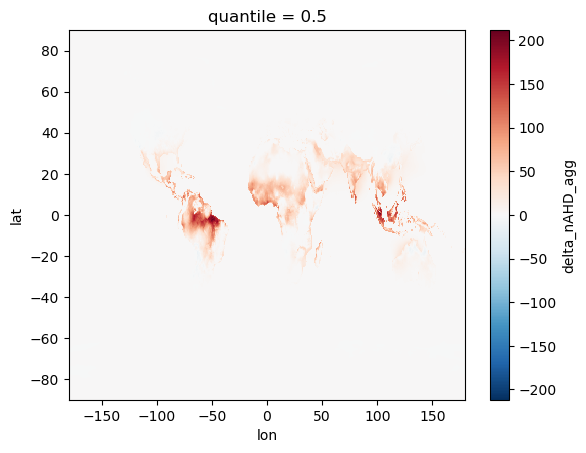

In [84]:
ds_out['delta_nAHD_agg'].isel(quantile=0).plot()

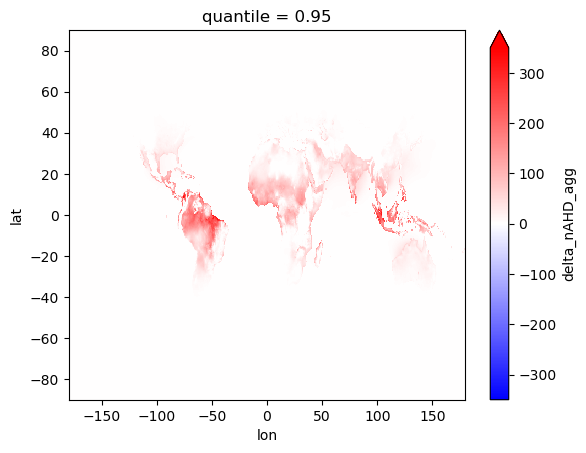

In [85]:
ds_out['delta_nAHD_agg'].isel(quantile=2).plot(vmin=-350,vmax=350,cmap='bwr')

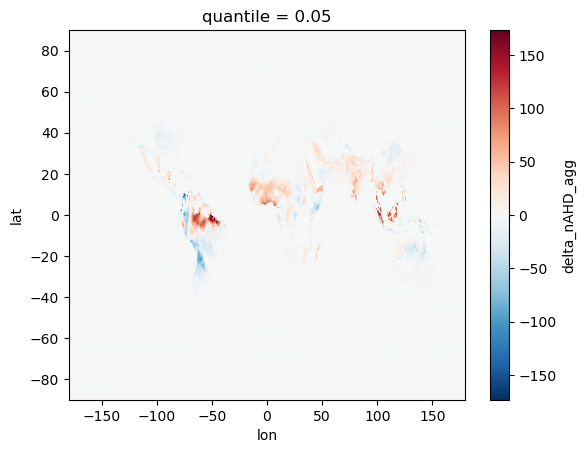

In [86]:
ds_out['delta_nAHD_agg'].isel(quantile=1).plot()

### correct

In [93]:
ds_out = calc_nAHD_shift_analytical_binom(
    da_params,
    threshold,
    gmst_smo,
    year_pres=2023,
    GWI=1.3,
    include_dataset_spread=False,
)

In [94]:
ds_out

<xarray.Dataset>
Dimensions:             (lat: 360, lon: 720, dataset: 3, quantile: 3)
Coordinates:
  * lat                 (lat) float32 89.75 89.25 88.75 ... -88.75 -89.25 -89.75
  * lon                 (lon) float32 -179.8 -179.2 -178.8 ... 178.8 179.2 179.8
  * dataset             (dataset) <U11 'GSWP3-W5E5' '20CRv3-ERA5' '20CRv3-W5E5'
  * quantile            (quantile) float64 0.5 0.05 0.95
Data variables:
    nHD_pres_dataset    (quantile, dataset, lat, lon) float64 4.576e-13 ... 0.0
    nHD_past_dataset    (quantile, dataset, lat, lon) float64 0.0 0.0 ... 0.0
    delta_nAHD_dataset  (quantile, dataset, lat, lon) float64 4.576e-13 ... 0.0
    nHD_pres_agg        (quantile, lat, lon) float64 6.883e-15 6.883e-15 ... 0.0
    nHD_past_agg        (quantile, lat, lon) float64 0.0 0.0 0.0 ... 0.0 0.0 0.0
    delta_nAHD_agg      (quantile, lat, lon) float64 6.883e-15 6.883e-15 ... 0.0

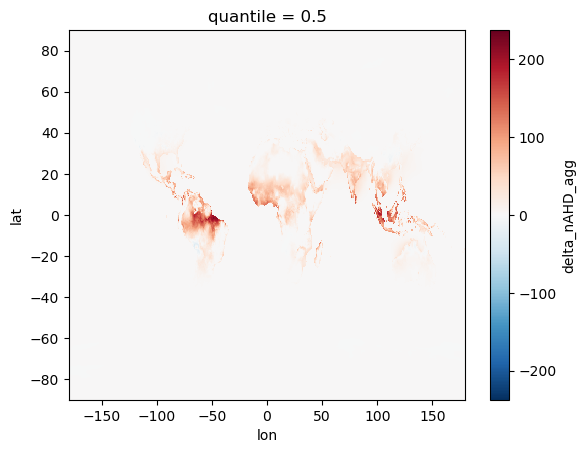

In [95]:
ds_out['delta_nAHD_agg'].isel(quantile=0).plot()

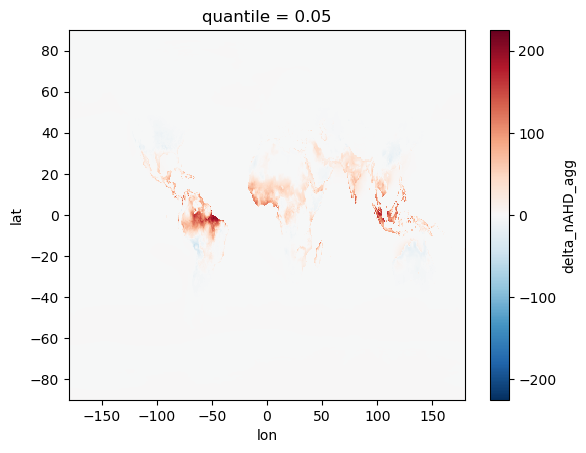

In [96]:
ds_out['delta_nAHD_agg'].isel(quantile=1).plot()

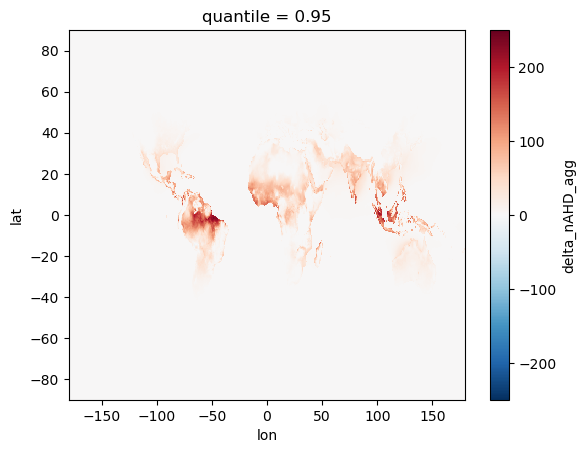

In [97]:
ds_out['delta_nAHD_agg'].isel(quantile=2).plot()

### pop exposure correct

comparing with and without dataset uncertainty 

In [100]:
ds_out

<xarray.Dataset>
Dimensions:             (lat: 360, lon: 720, dataset: 3, quantile: 3)
Coordinates:
  * lat                 (lat) float32 89.75 89.25 88.75 ... -88.75 -89.25 -89.75
  * lon                 (lon) float32 -179.8 -179.2 -178.8 ... 178.8 179.2 179.8
  * dataset             (dataset) <U11 'GSWP3-W5E5' '20CRv3-ERA5' '20CRv3-W5E5'
  * quantile            (quantile) float64 0.5 0.05 0.95
Data variables:
    nHD_pres_dataset    (quantile, dataset, lat, lon) float64 4.576e-13 ... 0.0
    nHD_past_dataset    (quantile, dataset, lat, lon) float64 0.0 0.0 ... 0.0
    delta_nAHD_dataset  (quantile, dataset, lat, lon) float64 4.576e-13 ... 0.0
    nHD_pres_agg        (quantile, lat, lon) float64 6.883e-15 6.883e-15 ... 0.0
    nHD_past_agg        (quantile, lat, lon) float64 0.0 0.0 0.0 ... 0.0 0.0 0.0
    delta_nAHD_agg      (quantile, lat, lon) float64 6.883e-15 6.883e-15 ... 0.0

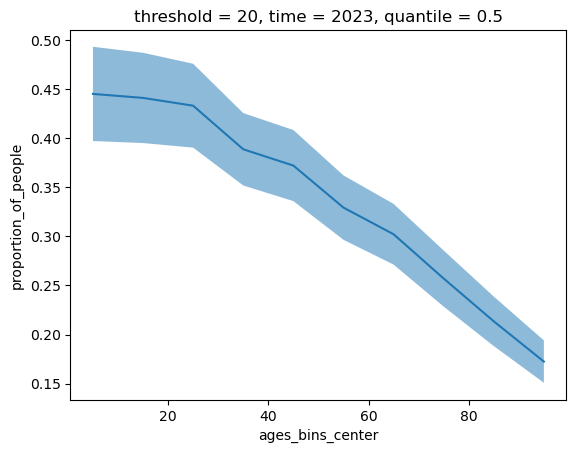

In [ ]:
fig, ax = plt.subplots()
da_prop.sel(threshold=20).sel(quantile=.5).plot(ax=ax)
ax.fill_between(np.arange(5,100,10), da_prop.sel(threshold=20).sel(quantile=.05).values.flatten(), da_prop.sel(threshold=20).sel(quantile=.95).values.flatten(),
alpha=.5
)

# include dataset uncertainty = False

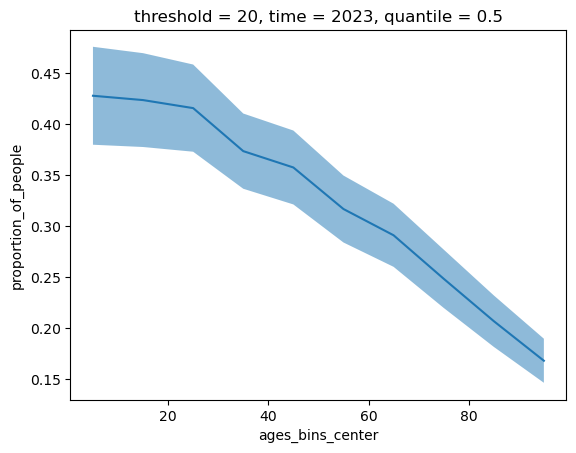

In [127]:
fig, ax = plt.subplots()
da_prop.sel(threshold=20).sel(quantile=.5).plot(ax=ax)
ax.fill_between(np.arange(5,100,10), da_prop.sel(threshold=20).sel(quantile=.05).values.flatten(), da_prop.sel(threshold=20).sel(quantile=.95).values.flatten(),
alpha=.5
)

# include dataset uncertainty = True

In [131]:
da_number, da_prop = calc_number_proportion_people_atleastxdays_analytical(
    gs_population_global,
    da_nAHD_dataset=ds_out['delta_nAHD_dataset'],
    age_ranges=np.arange(0, 105, 10),
    x_hot_days=[1,5,10,20,50],
    include_dataset_spread=False,
)

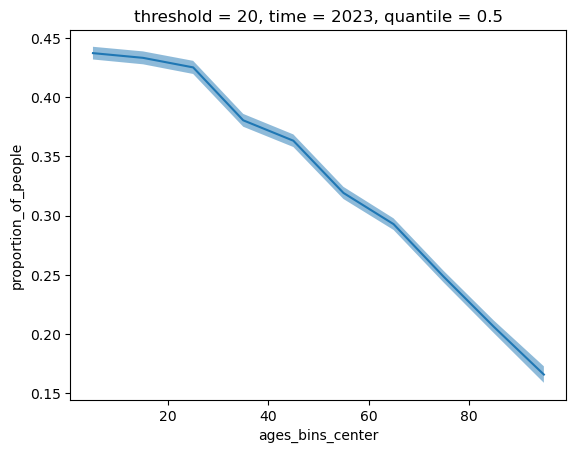

In [132]:
fig, ax = plt.subplots()
da_prop.sel(threshold=20).sel(quantile=.5).plot(ax=ax)
ax.fill_between(np.arange(5,100,10), da_prop.sel(threshold=20).sel(quantile=.05).values.flatten(), da_prop.sel(threshold=20).sel(quantile=.95).values.flatten(),
alpha=.5
)

# new fxn 

In [133]:
da_number, da_prop = calc_number_proportion_people_atleastxdays_analytical(
    gs_population_global,
    da_nAHD_dataset=ds_out['delta_nAHD_dataset'],
    age_ranges=np.arange(0, 105, 10),
    x_hot_days=[1,5,10,20,50],
    include_dataset_spread=True,
)

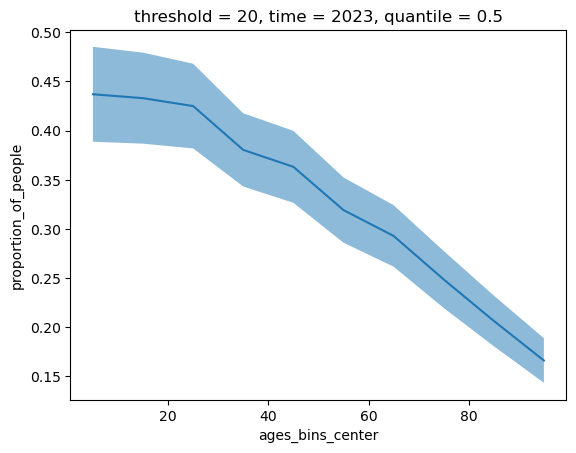

In [134]:
fig, ax = plt.subplots()
da_prop.sel(threshold=20).sel(quantile=.5).plot(ax=ax)
ax.fill_between(np.arange(5,100,10), da_prop.sel(threshold=20).sel(quantile=.05).values.flatten(), da_prop.sel(threshold=20).sel(quantile=.95).values.flatten(),
alpha=.5
)


In [136]:
da_percap_days = aggregate_percap_people_days_analytical(
    da_days_q_dataset = ds_out["delta_nAHD_dataset"],
    gs_population = gs_population_global,
    age_ranges=np.arange(0, 105, 10),
    include_dataset_spread=False,
)

In [137]:
da_percap_days

<xarray.DataArray 'percapita_days' (quantile: 3, time: 1, ages_bins: 10)>
array([[[27.86227851, 27.31469794, 26.52777376, 23.64932048,
         22.73405378, 20.13086825, 18.55959498, 15.86859078,
         13.22274076, 10.79239739]],

       [[27.6787354 , 27.12910059, 26.33975774, 23.46978009,
         22.55607961, 19.95718687, 18.39585788, 15.71407802,
         13.07000051, 10.61084431]],

       [[28.04582163, 27.5002953 , 26.71578978, 23.82886087,
         22.91202795, 20.30454964, 18.72333207, 16.02310354,
         13.37548101, 10.97395047]]])
Coordinates:
  * time       (time) int64 2023
  * ages_bins  (ages_bins) object [0, 10) [10, 20) ... [80, 90) [90, 100)
  * quantile   (quantile) float64 0.5 0.05 0.95

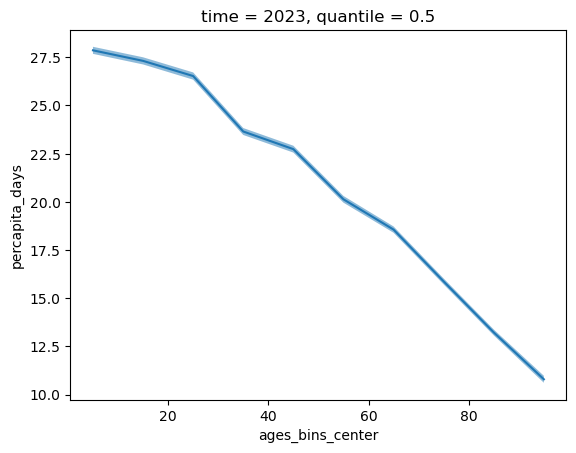

In [138]:
da = da_percap_days

fig, ax = plt.subplots()
da.sel(quantile=.5).plot(ax=ax)
ax.fill_between(np.arange(5,100,10), da.sel(quantile=.05).values.flatten(),da.sel(quantile=.95).values.flatten(),
alpha=.5
)

In [139]:
da_percap_days = aggregate_percap_people_days_analytical(
    da_days_q_dataset = ds_out["delta_nAHD_dataset"],
    gs_population = gs_population_global,
    age_ranges=np.arange(0, 105, 10),
    include_dataset_spread=True,
)

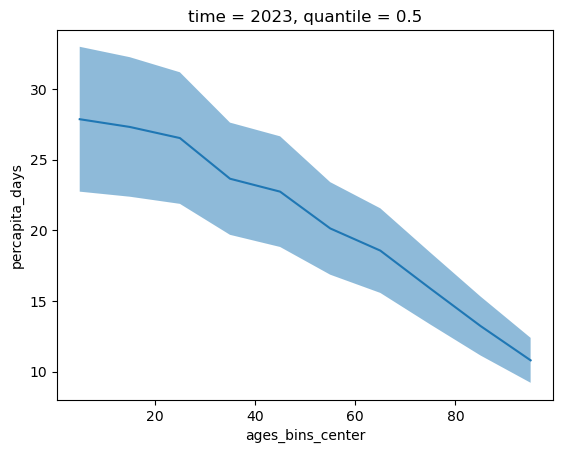

In [140]:
da = da_percap_days

fig, ax = plt.subplots()
da.sel(quantile=.5).plot(ax=ax)
ax.fill_between(np.arange(5,100,10), da.sel(quantile=.05).values.flatten(),da.sel(quantile=.95).values.flatten(),
alpha=.5
)

In [121]:
da_prop.sel(threshold=20).sel(quantile=.05).values.flatten()

array([0.39722031, 0.39515466, 0.39047678, 0.35190554, 0.33596564,
       0.29653467, 0.27126402, 0.22846552, 0.18821685, 0.15078838])

In [115]:
da_prop.sel(threshold=20).sel(quantile=.05)

<xarray.DataArray 'proportion_of_people' (time: 1, ages_bins: 10)>
array([[0.39722031, 0.39515466, 0.39047678, 0.35190554, 0.33596564,
        0.29653467, 0.27126402, 0.22846552, 0.18821685, 0.15078838]])
Coordinates:
    threshold  int64 20
  * time       (time) int64 2023
  * ages_bins  (ages_bins) object [0, 10) [10, 20) ... [80, 90) [90, 100)
    quantile   float64 0.05

## Testing

In [18]:
threshold = 28
year_pres = 2023 # for covariate fit
GWI=1.3


In [19]:
# ---- GMST ----
gmst_pres = gmst_smo.loc[year_pres].values
gmst_pi = gmst_pres - GWI

# ---- Parameters (dims: dataset, month, lat, lon) ----
b0 = da_params.sel(params='b0')
b1 = da_params.sel(params='b1')

mu_pres_np = (b0 + b1 * gmst_pres).values
mu_past_np = (b0 + b1 * (gmst_pres - GWI)).values

sigma_pres_np = sigma_past_np = da_params.sel(params='sigma').values


In [20]:
n_draws = 10

(array([7.105000e+03, 3.349400e+04, 6.638600e+04, 8.777600e+04,
        6.685300e+04, 5.331900e+04, 6.011200e+04, 7.927100e+04,
        9.296500e+04, 1.503210e+05, 2.633800e+05, 2.222430e+05,
        2.045330e+05, 1.866900e+05, 1.910110e+05, 1.863310e+05,
        2.693940e+05, 2.628480e+05, 4.232100e+05, 6.675610e+05,
        4.997120e+05, 5.101130e+05, 5.512270e+05, 6.206830e+05,
        6.837690e+05, 7.901600e+05, 1.457827e+06, 6.138030e+05,
        2.875300e+04, 3.140000e+02]),
 array([-61.50520811, -58.28823779, -55.07126747, -51.85429715,
        -48.63732683, -45.42035651, -42.20338619, -38.98641587,
        -35.76944556, -32.55247524, -29.33550492, -26.1185346 ,
        -22.90156428, -19.68459396, -16.46762364, -13.25065332,
        -10.033683  ,  -6.81671269,  -3.59974237,  -0.38277205,
          2.83419827,   6.05116859,   9.26813891,  12.48510923,
         15.70207955,  18.91904987,  22.13602019,  25.3529905 ,
         28.56996082,  31.78693114,  35.00390146]),
 <BarContainer

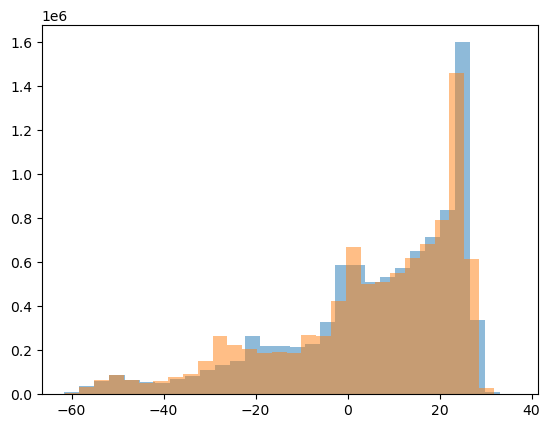

In [21]:
fig,ax=plt.subplots()
ax.hist(mu_pres_np.flatten(), bins=30, alpha=.5)
ax.hist(mu_past_np.flatten(),bins=30,alpha=.5)

(array([9.503440e+05, 1.140520e+06, 1.024915e+06, 1.299708e+06,
        9.951230e+05, 4.767170e+05, 3.706490e+05, 3.024190e+05,
        2.485450e+05, 2.579640e+05, 3.097710e+05, 3.628070e+05,
        3.506460e+05, 3.222650e+05, 2.744300e+05, 2.055710e+05,
        1.473960e+05, 9.972500e+04, 6.472000e+04, 4.107500e+04,
        2.878400e+04, 2.178900e+04, 1.582400e+04, 1.023600e+04,
        6.029000e+03, 2.485000e+03, 5.520000e+02, 1.390000e+02,
        1.300000e+01, 3.000000e+00]),
 array([ 0.2581451 ,  0.64892928,  1.03971346,  1.43049764,  1.82128182,
         2.212066  ,  2.60285017,  2.99363435,  3.38441853,  3.77520271,
         4.16598689,  4.55677107,  4.94755525,  5.33833943,  5.72912361,
         6.11990779,  6.51069197,  6.90147615,  7.29226033,  7.68304451,
         8.07382868,  8.46461286,  8.85539704,  9.24618122,  9.6369654 ,
        10.02774958, 10.41853376, 10.80931794, 11.20010212, 11.5908863 ,
        11.98167048]),
 <BarContainer object of 30 artists>)

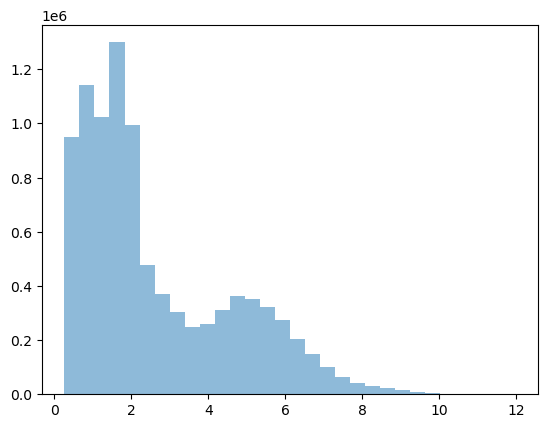

In [22]:
plt.hist(sigma_pres_np.flatten(),bins=30,alpha=.5)

In [24]:
p_pres = 1 - norm.cdf((threshold - mu_pres_np) / sigma_pres_np)
p_past = 1 - norm.cdf((threshold - mu_past_np) / sigma_past_np)



In [25]:
# get nan / failed fits
valid_mask = np.isfinite(p_pres) & np.isfinite(p_past)

In [29]:
p_pres = np.nan_to_num(p_pres, nan=0.0)
p_past = np.nan_to_num(p_past, nan=0.0)

In [28]:
valid_mask.shape

(3, 12, 360, 720)

In [43]:
p_pres.shape

(3, 12, 360, 720)

(array([9004089.,   78165.,   47904.,   35996.,   29700.,   26064.,
          25346.,   25466.,   26243.,   32191.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

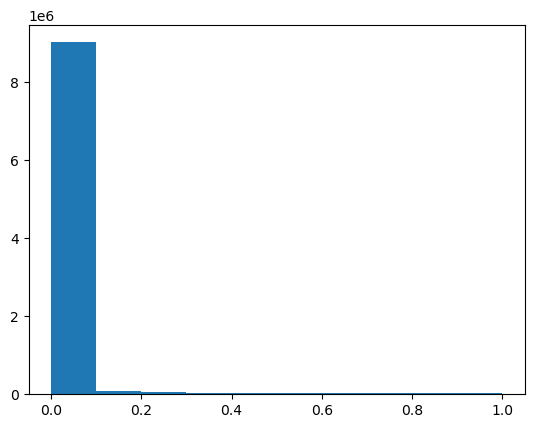

In [47]:
plt.hist(p_pres.flatten())

In [30]:
print("min p:", np.nanmin(p_pres))
print("max p:", np.nanmax(p_pres))
print("any NaN:", np.isnan(p_pres).any())

min p: 0.0
max p: 1.0
any NaN: False


In [31]:
    # ---- Days per month ----
    days_in_month = np.array([31,28,31,30,31,30,31,31,30,31,30,31])

    # reshape for broadcasting: (1, 1, month, 1, 1)
    days = days_in_month[None, None, :, None, None]

In [32]:
p_pres.shape

(3, 12, 360, 720)

In [39]:
days_exceed_pres = np.random.binomial(
    days,
    p_pres,
    size=(n_draws,) + p_pres.shape
    ).astype(float)

In [40]:
    days_exceed_past = np.random.binomial(
        days,
        p_past,
        size=(n_draws,) + p_past.shape
    ).astype(float)

In [41]:
days_exceed_past.shape

(10, 3, 12, 360, 720)

(array([9.1260185e+07, 5.6876300e+05, 3.6541100e+05, 2.7474700e+05,
        2.2072300e+05, 1.7803000e+05, 1.4367000e+05, 1.1279300e+05,
        8.8345000e+04, 9.9333000e+04]),
 array([ 0. ,  3.1,  6.2,  9.3, 12.4, 15.5, 18.6, 21.7, 24.8, 27.9, 31. ]),
 <BarContainer object of 10 artists>)

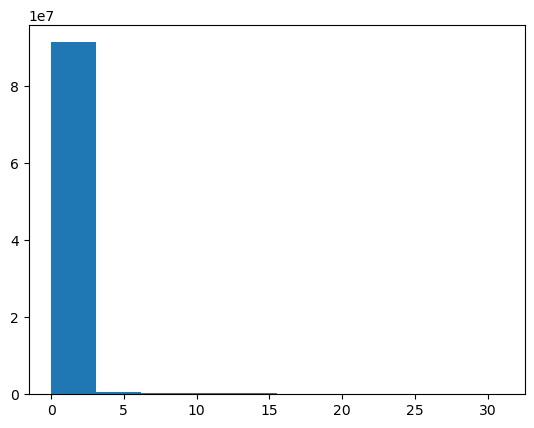

In [42]:
plt.hist(days_exceed_past.flatten())

In [43]:
days_exceed_pres[:, ~valid_mask] = np.nan
days_exceed_past[:, ~valid_mask] = np.nan

In [58]:
    nAHD_pres = days_exceed_pres.sum(axis=2)
    nAHD_past = days_exceed_past.sum(axis=2)

In [59]:
    delta_nAHD = nAHD_pres - nAHD_past


In [60]:

    # ---- Convert back to xarray ----
    da_nAHD_MC = xr.DataArray(
        delta_nAHD,
        dims=['draw', 'dataset', 'lat', 'lon'],
        coords={
            'draw': np.arange(n_draws),
            'dataset': da_params.dataset,
            'lat': da_params.lat,
            'lon': da_params.lon
        }
    )

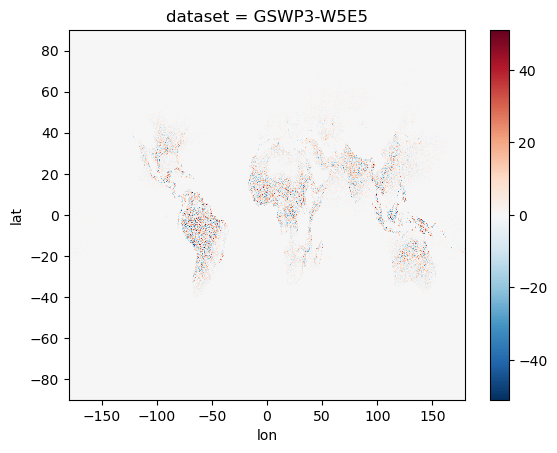

In [65]:
(da_nAHD_MC.isel(draw=2,dataset=0) - da_nAHD_MC.isel(draw=5,dataset=0) ).plot()

In [10]:
threshold = 28
year_pres = 2023 # for covariate fit
GWI=1.3


In [37]:
da_nAHD_MC, da_nAHD_summary= calc_nAHD_shift_MC(da_params, threshold, gmst_smo, n_draws=10, year_pres=2023, GWI=1.3)

In [38]:
da_nAHD_combined = aggregate_nAHD_MC(da_nAHD_MC) # summary


In [42]:
da_percap_days_combined = aggregate_people_days_MC(da_nAHD_MC, gs_population_global) 

In [45]:
people_days_med_comb_spatial = (gs_population_global * da_nAHD_MC).stack(all=('draw','dataset')).median(dim='all')


In [47]:
da_number, da_prop = calc_number_proportion_people_atleastxdays_MC(
                                    gs_population_global,
                                    da_nAHD_MC,
                                    age_ranges=np.arange(0, 105, 10),
                                    x_hot_days=[1,5,10,20,50]
                                )


In [49]:
da_prop

<xarray.DataArray 'proportion_of_people' (threshold: 5, quantile: 3, time: 1,
                                          ages_bins: 10)>
array([[[[0.42193164, 0.41787099, 0.41049488, 0.37389682, 0.36173833,
          0.32609207, 0.30227754, 0.26485391, 0.22678084, 0.19255974]],

        [[0.36777345, 0.36606052, 0.36152824, 0.33191855, 0.31844021,
          0.28953821, 0.26803826, 0.23367708, 0.19910906, 0.16993083]],

        [[0.43437838, 0.42989468, 0.42126768, 0.38313174, 0.36986809,
          0.33492842, 0.31209618, 0.2778127 , 0.24875095, 0.22744819]]],


       [[[0.41893912, 0.41488787, 0.40775409, 0.37203694, 0.36005214,
          0.32455301, 0.3012185 , 0.26418347, 0.22592051, 0.19143801]],

        [[0.36598998, 0.36435437, 0.360111  , 0.33066964, 0.31732521,
          0.2884995 , 0.26712099, 0.23286679, 0.19814101, 0.16927076]],

        [[0.43221316, 0.42747821, 0.41938506, 0.38238344, 0.36928852,
          0.33435676, 0.3117902 , 0.27755439, 0.24848543, 0.22711969]]],


...


       [[[0.41893912, 0.41488787, 0.40775409, 0.37203694, 0.36005214,
          0.32455301, 0.3012185 , 0.26418347, 0.22592051, 0.19143801]],

        [[0.36598998, 0.36435437, 0.360111  , 0.33066964, 0.31732521,
          0.2884995 , 0.26712099, 0.23286679, 0.19814101, 0.16927076]],

        [[0.43221316, 0.42747821, 0.41938506, 0.38238344, 0.36928852,
          0.33435676, 0.3117902 , 0.27755439, 0.24848543, 0.22711969]]],


       [[[0.24962362, 0.24418369, 0.23619692, 0.20915655, 0.20012921,
          0.17628122, 0.16134952, 0.13563269, 0.11049054, 0.08584826]],

        [[0.19490588, 0.19214185, 0.18889398, 0.16838893, 0.16068638,
          0.14140284, 0.1301407 , 0.1100149 , 0.09217635, 0.07634497]],

        [[0.26038732, 0.25573092, 0.24852454, 0.22160729, 0.2131299 ,
          0.18815211, 0.17209721, 0.14632547, 0.12097609, 0.09692249]]]])
Coordinates:
  * threshold  (threshold) int64 1 5 10 20 50
  * time       (time) int64 2023
  * ages_bins  (ages_bins) object [0, 10) [10, 20) ... [80, 90) [90, 100)
  * quantile   (quantile) float64 0.5 0.05 0.95

In [30]:
da_nAHD_summary

<xarray.DataArray (quantile: 3, dataset: 3, lat: 360, lon: 720)>
array([[[[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]],

        [[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]],

        [[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
...
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]],

        [[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]],

        [[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]]]])
Coordinates:
  * dataset   (dataset) <U11 'GSWP3-W5E5' '20CRv3-ERA5' '20CRv3-W5E5'
  * lat       (lat) float32 89.75 89.25 88.75 88.25 ... -88.75 -89.25 -89.75
  * lon       (lon) float32 -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
  * quantile  (quantile) float64 0.5 0.05 0.95

In [31]:
# stack draws and datasets together
combined = da_nAHD_MC.stack(all=('draw','dataset'))

# median and 5-95% range including both natural variability and dataset differences
median = combined.median(dim='all')
p5 = combined.quantile(0.05, dim='all')
p95 = combined.quantile(0.95, dim='all')

In [32]:
median

<xarray.DataArray (lat: 360, lon: 720)>
array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])
Coordinates:
  * lat      (lat) float32 89.75 89.25 88.75 88.25 ... -88.75 -89.25 -89.75
  * lon      (lon) float32 -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8

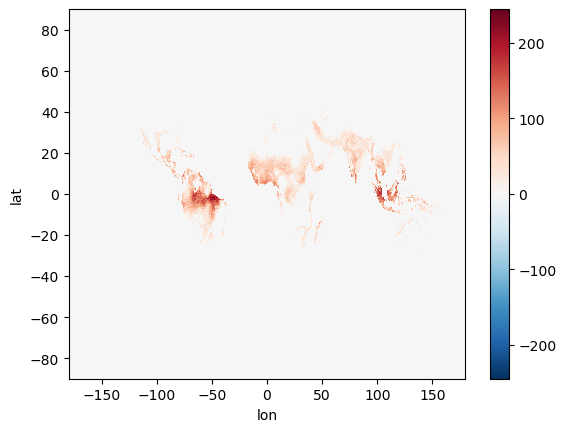

In [33]:
median.plot()

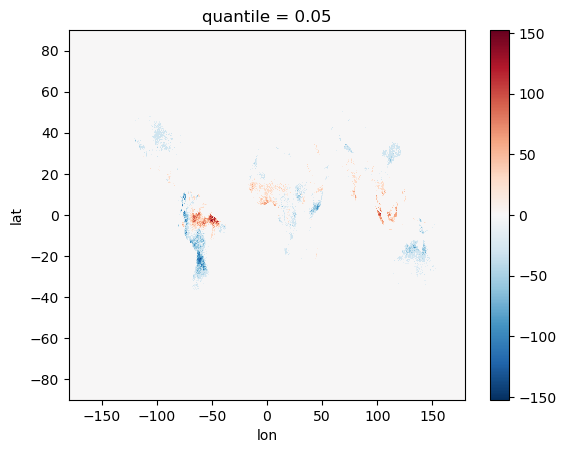

In [34]:
p5.plot()

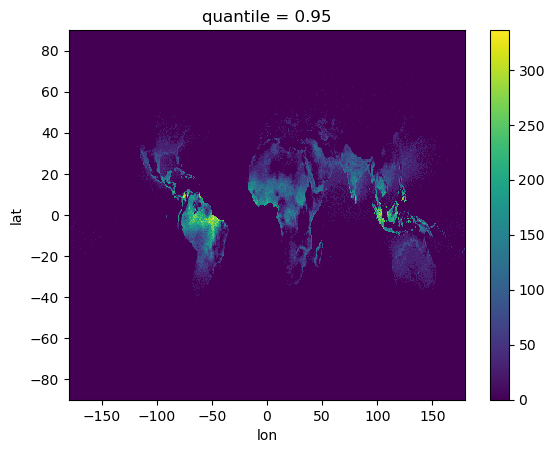

In [35]:
p95.plot()

loading country masks
interpolating cohort sizes per country
calculating gridscale demographics


In [22]:
people_days = (gs_population_global * da_nAHD_MC).sum(dim=('lat','lon'))

In [32]:
people_days.stack(all=('draw','dataset')).median(dim='all') / gs_population_global.sum(dim=['lat','lon'])

<xarray.DataArray (time: 1, ages: 105)>
array([[ 76.75371618,  76.60782268,  76.46240081,  76.30897023,
         76.15591134,  75.91222561,  75.75763887,  75.60356395,
         75.60965314,  75.61575922,  75.59069635,  75.58738986,
         75.58407559,  75.7933926 ,  76.00640226,  76.46150564,
         76.68145911,  76.9053389 ,  76.94143393,  76.97818476,
         77.15675212,  77.19352351,  77.23097706,  76.82815215,
         76.42254723,  75.94771272,  75.53071387,  75.11096342,
         74.33061221,  73.55447342,  72.33801851,  71.55762923,
         70.78219061,  70.36810943,  69.94885437,  69.45010164,
         68.98782083,  68.52045439,  68.52989371,  68.53973069,
         69.10317151,  69.10960686,  69.11632572,  68.64175196,
         68.15231933,  67.43557133,  66.91078874,  66.36930829,
         65.68206701,  64.98049847,  63.98441211,  63.23970191,
         62.49234421,  62.04113262,  61.57178511,  61.12540889,
         60.60330214,  60.05919216,  59.73409721,  59.38760602,
         59.19306123,  58.78126198,  58.33970404,  57.80733137,
         57.23238105,  56.51589954,  55.82931024,  55.08110951,
         54.37806705,  53.60043978,  52.31873119,  51.33526254,
         50.23072607,  49.78098656,  49.25863821,  48.75881539,
         47.9688993 ,  47.01330835,  46.52631498,  45.9504905 ,
         45.23918399,  44.371788  ,  43.2888007 ,  42.70679997,
         41.99482605,  40.51546269,  39.37818498,  37.85916729,
         37.57568986,  37.20276534,  36.5316534 ,  35.78188698,
         34.54122645,  34.49859337,  34.43818892,  34.58402483,
         34.46383896,  34.21571808,  34.49106976,  34.90657741,
         38.82288849,  40.31669596,  44.83860557,  91.77270615,
        114.624614  ]])
Coordinates:
  * time     (time) int64 2023
  * ages     (ages) int64 0 1 2 3 4 5 6 7 8 ... 96 97 98 99 100 101 102 103 104

In [52]:
da_params.chunk(chunks='auto')

<xarray.DataArray 'fit_params' (dataset: 3, month: 12, lat: 360, lon: 720,
                                params: 3)>
dask.array<xarray-<this-array>, shape=(3, 12, 360, 720, 3), dtype=float64, chunksize=(3, 12, 360, 431, 3), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float32 89.75 89.25 88.75 88.25 ... -88.75 -89.25 -89.75
  * lon      (lon) float32 -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
  * month    (month) int64 1 2 3 4 5 6 7 8 9 10 11 12
  * params   (params) object 'b0' 'b1' 'sigma'
  * dataset  (dataset) <U11 'GSWP3-W5E5' '20CRv3-ERA5' '20CRv3-W5E5'